In [12]:
from pathlib import Path

DATASET_PATH = Path("../dataset/raw")

print("Dataset path:", DATASET_PATH.resolve())
print("Dataset exists:", DATASET_PATH.exists())

Dataset path: D:\AiMl\dataset\raw
Dataset exists: True


In [13]:
train_path = DATASET_PATH / "train"

classes = sorted([folder.name for folder in train_path.iterdir() if folder.is_dir()])

print("Number of classes:", len(classes))
print("Classes:")
for class_name in classes:
    print("-", class_name)

Number of classes: 10
Classes:
- Battery
- Keyboard
- Microwave
- Mobile
- Mouse
- PCB
- Player
- Printer
- Television
- Washing Machine


Image: battery_0.jpg
Image size: (150, 150)
Image mode: RGB


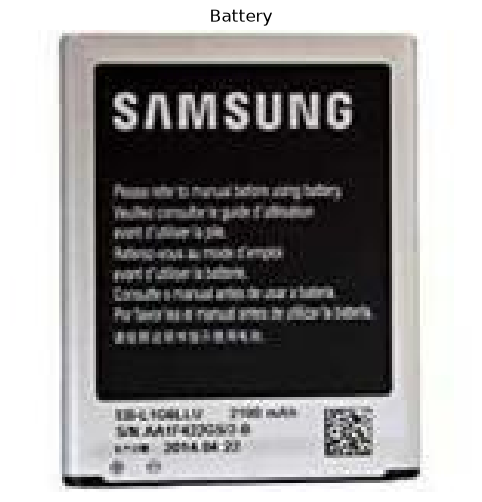

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

# Battery class ki images
battery_path = DATASET_PATH / "train" / "Battery"

# Pehli image
image_file = list(battery_path.iterdir())[0]

# Image open karo
image = Image.open(image_file)

print("Image:", image_file.name)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Battery")
plt.show()

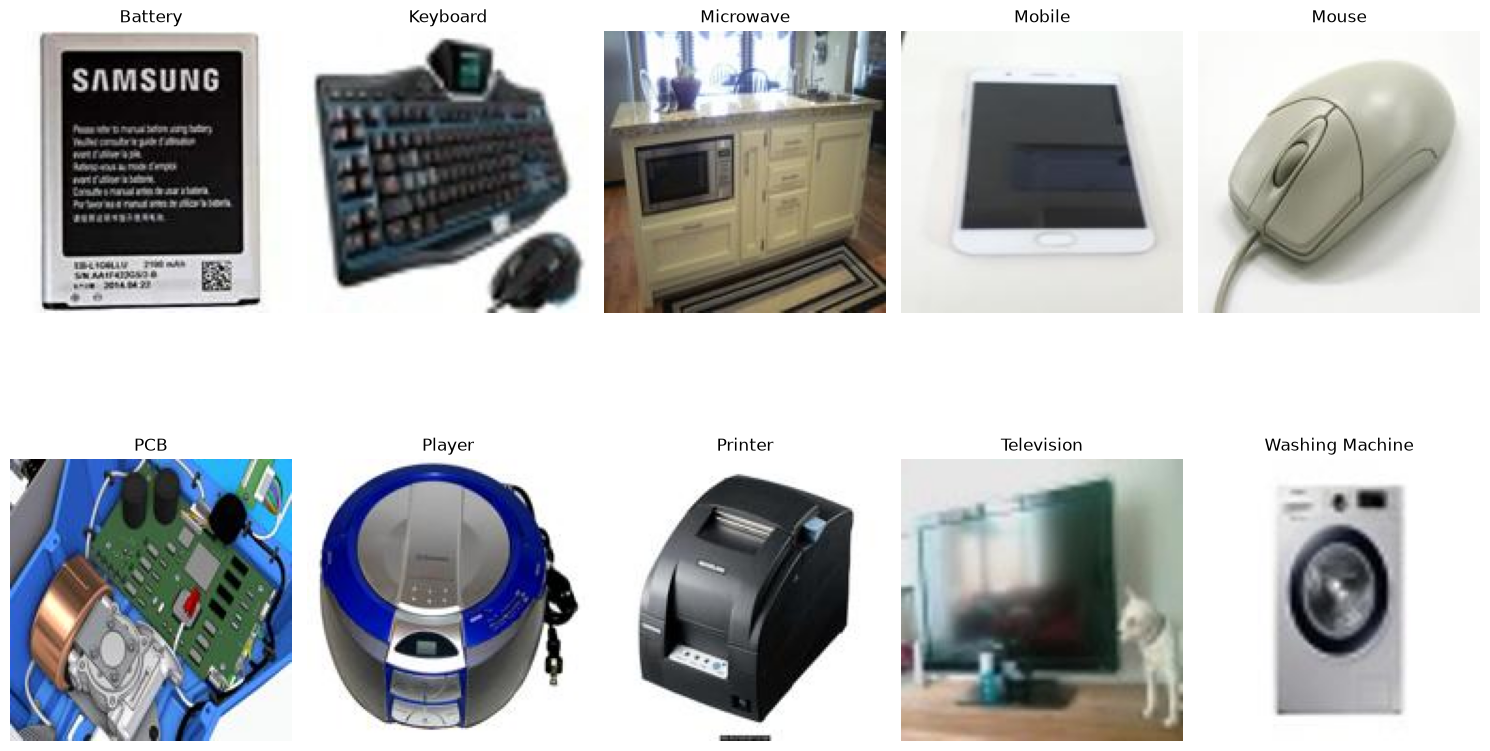

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):
    class_path = DATASET_PATH / "train" / class_name
    
    # Class ki first image
    image_file = list(class_path.iterdir())[0]
    image = Image.open(image_file)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
from collections import Counter
from PIL import Image

image_sizes = []

for class_name in classes:
    class_path = DATASET_PATH / "train" / class_name

    for image_file in class_path.iterdir():
        try:
            with Image.open(image_file) as img:
                image_sizes.append(img.size)
        except:
            pass

size_counts = Counter(image_sizes)

print("Total images checked:", len(image_sizes))
print("\nMost common image sizes:")

for size, count in size_counts.most_common(10):
    print(size, "->", count, "images")

Total images checked: 2400

Most common image sizes:
(150, 150) -> 2400 images


In [17]:
from collections import Counter
from PIL import Image

image_modes = Counter()

for class_name in classes:
    class_path = DATASET_PATH / "train" / class_name

    for image_file in class_path.iterdir():
        try:
            with Image.open(image_file) as img:
                image_modes[img.mode] += 1
        except:
            pass

print("Image modes:")
for mode, count in image_modes.items():
    print(mode, "->", count)

Image modes:
RGB -> 2400


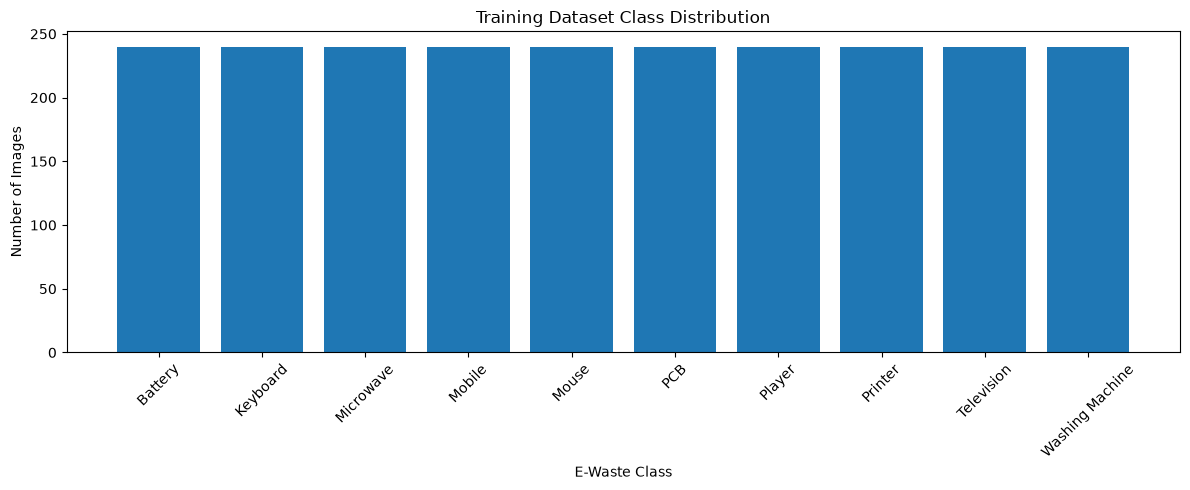

In [18]:
import matplotlib.pyplot as plt

train_counts = []

for class_name in classes:
    class_path = DATASET_PATH / "train" / class_name
    count = len(list(class_path.iterdir()))
    train_counts.append(count)

plt.figure(figsize=(12, 5))
plt.bar(classes, train_counts)

plt.xlabel("E-Waste Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()